# Feature Importance

In [4]:
import json
import pandas as pd

from models.encoder.common import METRICS_DIR
from evaluation.encoder.helpers import (
    export_feature_importance_latex,
    plot_feature_importance_bars,
)

FEATURE_NAME_MAPPING = {
    "extract_word_length_by_char": "Word Length",
    "extract_ngram_word_length_by_char": "Word Length Trigram",
    "extract_sentence_length_by_word": "Sentence Length",
    "extract_char_ngrams": "Character N-Gram Frequency",
    "extract_punctuation": "Punctuation Frequency",
    "extract_pos_frequency": "Morph. POS Frequency",
    "extract_pos_ngrams": "Morph. POS N-Gram Frequency",
    "extract_dependency_tree_structure": "Dep. Tree Structure",
    "extract_dependency_tree_relations": "Dep. Tree N-Gram Frequency",
    "extract_casing": "Casing-Position Frequency",
    "extract_casing_bigrams": "Casing Bigram Frequency",
    "extract_ttr": "Type-Token Ratio (TTR)",
    "extract_lexical_density": "Lexical Density",
    "extract_sentence_length_by_word_avg": "Sentence Length Average",
    "extract_syllable_count_avg": "Syllable Count Average",
    "extract_3+syllable_count_ratio": "3+ Syllable Word Ratio",
    "extract_stopwords": "Stopword Ratio",
    "extract_noun_phrase_lengths": "Noun Phrase Frequency",
    "extract_supersense": "Supersense Frequency",
    "extract_entity_categories": "Named Entity Frequency",
    "extract_events": "Event Ratio",
    "extract_places": "Place Ratio",
    "extract_tense": "Tense Ratio",
    "extract_numeric_word_ratio": "Numeric Word Ratio",
    "extract_quote_ratio": "Quote Ratio",
    "extract_contractions": "Contraction Ratio",
    "extract_articles": "Article Ratio",
    "extract_word_concreteness": "Word Concreteness Frequency",
    "extract_word_concreteness_avg": "Word Concreteness Average",
    "extract_preposition_imageability": "Preposition Imageability Frequency",
    "extract_preposition_imageability_avg": "Preposition Imageability Average",
    "extract_polysemy": "Polysemy Frequency",
}


def load_metrics(pattern):
    """Load and average metrics from JSON files matching the pattern."""
    files = list((METRICS_DIR / "feature-importance").glob(pattern))
    if not files:
        return None
    all_metrics = []
    for filepath in files:
        with open(filepath, "r") as f:
            metrics = json.load(f)
            all_metrics.append(metrics)
    if not all_metrics:
        return None
    # Average the metrics
    averaged = {}
    scalar_keys = ["mse", "accuracy"]
    list_keys = ["f1", "support"]
    for key in scalar_keys:
        values = [m.get(key, 0) for m in all_metrics]
        averaged[key] = sum(values) / len(values) if values else 0
    for key in list_keys:
        lists = [m.get(key, []) for m in all_metrics]
        if lists and all(len(lst) == len(lists[0]) for lst in lists):
            averaged[key] = [sum(x) / len(lists) for x in zip(*lists)]
        else:
            averaged[key] = []
    return {"averaged": averaged, "all": all_metrics}


# Load baseline (all features)
baseline_metrics = load_metrics("catboost_minilm_test_*.json")
if baseline_metrics:
    baseline_averaged = baseline_metrics["averaged"]
    baseline_all = baseline_metrics["all"]
else:
    baseline_averaged = None
    baseline_all = None

# Load features only (no embeddings)
features_only_metrics = load_metrics("catboost_minilm_features-minilm_test_*.json")
if features_only_metrics:
    features_only_averaged = features_only_metrics["averaged"]
    features_only_all = features_only_metrics["all"]
else:
    features_only_averaged = None
    features_only_all = None

# Load metrics for each removed feature group
removed_group_averaged = {}
removed_group_all = {}
for group in FEATURE_NAME_MAPPING.keys():
    metrics = load_metrics(f"catboost_minilm_features-{group}_test_*.json")
    if metrics:
        removed_group_averaged[group] = metrics["averaged"]
        removed_group_all[group] = metrics["all"]
    else:
        removed_group_averaged[group] = None
        removed_group_all[group] = None

print(f"Loaded baseline metrics: {baseline_averaged is not None}")
print(f"Loaded features-only metrics: {features_only_averaged is not None}")
print(
    f"Loaded {sum(1 for m in removed_group_averaged.values() if m is not None)}/{len(FEATURE_NAME_MAPPING)} removed group metrics"
)

# Debug: print averaged values
if baseline_averaged:
    print(
        f"Baseline averaged MSE: {baseline_averaged['mse']:.4f}, Accuracy: {baseline_averaged['accuracy']:.4f}"
    )
if features_only_averaged:
    print(
        f"Features-only averaged MSE: {features_only_averaged['mse']:.4f}, Accuracy: {features_only_averaged['accuracy']:.4f}"
    )

Loaded baseline metrics: True
Loaded features-only metrics: True
Loaded 32/32 removed group metrics
Baseline averaged MSE: 0.9595, Accuracy: 0.3982
Features-only averaged MSE: 0.9753, Accuracy: 0.3923


In [5]:
import math
import numpy as np

rows = []


def macro_f1(m):
    return sum(m["f1"]) / len(m["f1"]) if m else None


def weighted_f1(m):
    if not m or not m.get("f1") or not m.get("support"):
        return None
    total = sum(m["support"])
    if total == 0:
        return None
    return sum(f * s for f, s in zip(m["f1"], m["support"])) / total


def delta_stats(all_metrics, baseline_metrics, value_fn):
    if not baseline_metrics or not all_metrics:
        return float("nan"), float("nan")
    deltas = [value_fn(g) - value_fn(b) for g, b in zip(all_metrics, baseline_metrics)]
    if not deltas:
        return float("nan"), float("nan")
    mean_delta = float(np.mean(deltas))
    std_delta = float(np.std(deltas, ddof=1)) if len(deltas) > 1 else 0.0
    return mean_delta, 2 * std_delta


baseline_macro_f1 = None
if baseline_averaged:
    baseline_rmse = math.sqrt(baseline_averaged["mse"])
    baseline_macro_f1 = macro_f1(baseline_averaged)
    rows.append(
        {
            "Removed Feature Group": "None – Baseline",
            "RMSE": baseline_rmse,
            "Accuracy": baseline_averaged["accuracy"],
            "Macro Avg F1": baseline_macro_f1,
            "F1w": weighted_f1(baseline_averaged),
            "RMSE Δ": 0.0,
            "RMSE 2σ": 0.0,
            "Accuracy Δ": 0.0,
            "Accuracy 2σ": 0.0,
            "Macro F1 Δ": 0.0,
            "Macro F1 2σ": 0.0,
            "F1w Δ": 0.0,
            "F1w 2σ": 0.0,
        }
    )

if features_only_averaged:
    features_only_rmse = math.sqrt(features_only_averaged["mse"])
    rmse_delta_mean, rmse_delta_2sigma = delta_stats(
        features_only_all, baseline_all, lambda m: math.sqrt(m["mse"])
    )
    acc_delta_mean, acc_delta_2sigma = delta_stats(
        features_only_all, baseline_all, lambda m: m["accuracy"]
    )
    macro_delta_mean, macro_delta_2sigma = delta_stats(
        features_only_all, baseline_all, macro_f1
    )
    f1w_delta_mean, f1w_delta_2sigma = delta_stats(
        features_only_all, baseline_all, weighted_f1
    )
    rows.append(
        {
            "Removed Feature Group": "MiniLM embeddings",
            "RMSE": features_only_rmse,
            "Accuracy": features_only_averaged["accuracy"],
            "Macro Avg F1": macro_f1(features_only_averaged),
            "F1w": weighted_f1(features_only_averaged),
            "RMSE Δ": rmse_delta_mean,
            "RMSE 2σ": rmse_delta_2sigma,
            "Accuracy Δ": acc_delta_mean,
            "Accuracy 2σ": acc_delta_2sigma,
            "Macro F1 Δ": macro_delta_mean,
            "Macro F1 2σ": macro_delta_2sigma,
            "F1w Δ": f1w_delta_mean,
            "F1w 2σ": f1w_delta_2sigma,
        }
    )

for group in FEATURE_NAME_MAPPING.keys():
    metrics = removed_group_averaged[group]
    all_metrics = removed_group_all[group]
    if metrics:
        human_name = FEATURE_NAME_MAPPING.get(
            group, group.replace("extract_", "").replace("_", " ").title()
        )
        rmse_delta_mean, rmse_delta_2sigma = delta_stats(
            all_metrics, baseline_all, lambda m: math.sqrt(m["mse"])
        )
        acc_delta_mean, acc_delta_2sigma = delta_stats(
            all_metrics, baseline_all, lambda m: m["accuracy"]
        )
        macro_delta_mean, macro_delta_2sigma = delta_stats(
            all_metrics, baseline_all, macro_f1
        )
        f1w_delta_mean, f1w_delta_2sigma = delta_stats(
            all_metrics, baseline_all, weighted_f1
        )
        rows.append(
            {
                "Removed Feature Group": human_name,
                "RMSE": math.sqrt(metrics["mse"]),
                "Accuracy": metrics["accuracy"],
                "Macro Avg F1": macro_f1(metrics),
                "F1w": weighted_f1(metrics),
                "RMSE Δ": rmse_delta_mean,
                "RMSE 2σ": rmse_delta_2sigma,
                "Accuracy Δ": acc_delta_mean,
                "Accuracy 2σ": acc_delta_2sigma,
                "Macro F1 Δ": macro_delta_mean,
                "Macro F1 2σ": macro_delta_2sigma,
                "F1w Δ": f1w_delta_mean,
                "F1w 2σ": f1w_delta_2sigma,
            }
        )

df = pd.DataFrame(rows)

# Configuration options
columns_to_include = [
    "Removed Feature Group",
    "RMSE",
    "RMSE Δ",
    "F1w Δ",
    # "Macro F1 Δ",
]
sort_column = "RMSE Δ"
sort_ascending = False
# gradient_columns: list of columns to apply gradient. Prefix with "-" to reverse direction (higher = better)
gradient_columns = ["-RMSE Δ", "F1w Δ"]

# Apply selections
print(df)
df = df[columns_to_include]
df = df.sort_values(sort_column, ascending=sort_ascending).reset_index(drop=True)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


def highlight_baselines(row):
    config = row["Removed Feature Group"]
    if "Baseline" in config:
        return ["font-weight: bold;"] * len(row)
    return [""] * len(row)


# Dynamic format dict for numeric columns
format_dict = {
    col: "{:.4f}" for col in df.columns if col not in ["Removed Feature Group"]
}

styled_df = df.style.format(format_dict).apply(highlight_baselines, axis=1)

# Apply gradients to specified columns
for grad_col in gradient_columns:
    if grad_col.startswith("-"):
        actual_col = grad_col[1:]
        cmap = "RdYlGn"  # Green to red: higher values better
    else:
        actual_col = grad_col
        cmap = "RdYlGn_r"  # Red to green: higher values worse
    if actual_col in df.columns:
        # Center the gradient at 0 (yellow) by using symmetric min/max
        abs_max = max(abs(df[actual_col].min()), abs(df[actual_col].max()))
        vmin = -abs_max
        vmax = abs_max
        styled_df = styled_df.background_gradient(
            subset=[actual_col], cmap=cmap, vmin=vmin, vmax=vmax
        )
styled_df

                 Removed Feature Group   RMSE  Accuracy  Macro Avg F1    F1w  \
0                      None – Baseline 0.9795    0.3982        0.3251 0.3839   
1                    MiniLM embeddings 0.9876    0.3923        0.3160 0.3753   
2                          Word Length 0.9774    0.3923        0.3070 0.3723   
3                  Word Length Trigram 0.9818    0.3835        0.3068 0.3669   
4                      Sentence Length 0.9776    0.3894        0.3093 0.3712   
5           Character N-Gram Frequency 1.0078    0.3850        0.3115 0.3638   
6                Punctuation Frequency 0.9753    0.3805        0.2987 0.3589   
7                 Morph. POS Frequency 0.9765    0.3894        0.3095 0.3668   
8          Morph. POS N-Gram Frequency 0.9613    0.4027        0.3196 0.3866   
9                  Dep. Tree Structure 0.9817    0.3864        0.3030 0.3631   
10          Dep. Tree N-Gram Frequency 0.9619    0.3909        0.3154 0.3726   
11           Casing-Position Frequency 0

,Removed Feature Group,RMSE,RMSE Δ,F1w Δ
0,Supersense Frequency,1.0202,0.0413,-0.0197
1,Character N-Gram Frequency,1.0078,0.0304,0.0052
2,Word Concreteness Frequency,0.9980,0.0231,-0.0301
3,Article Ratio,0.9920,0.0202,-0.0252
4,MiniLM embeddings,0.9876,0.0197,-0.0078
5,Syllable Count Average,0.9858,0.0150,-0.0261
6,Preposition Imageability Frequency,0.9806,0.0119,-0.0335
7,Sentence Length,0.9776,0.0115,-0.0082
8,Stopword Ratio,0.9822,0.0102,-0.0359
9,Numeric Word Ratio,0.9796,0.0084,-0.0127


In [6]:
export_feature_importance_latex(df)

\begin{table}[hbtp]
\centering
\small
\begin{tabular}{lrrr}
\toprule
\textbf{Removed Feature Group} & \textbf{RMSE} $\downarrow$ & \textbf{RMSE $\Delta$} & \textbf{F1w $\Delta$} \\
\midrule
Supersense Frequency & 1.020 & \cellcolor[rgb]{0.000,0.408,0.216}0.041 & -0.020 \\
Character N-Gram Frequency & 1.008 & \cellcolor[rgb]{0.190,0.639,0.336}0.030 & 0.005 \\
Word Concreteness Frequency & 0.998 & \cellcolor[rgb]{0.449,0.763,0.394}0.023 & -0.030 \\
Article Ratio & 0.992 & \cellcolor[rgb]{0.538,0.801,0.403}0.020 & -0.025 \\
MiniLM embeddings & 0.988 & \cellcolor[rgb]{0.548,0.806,0.404}0.020 & -0.008 \\
Syllable Count Average & 0.986 & \cellcolor[rgb]{0.686,0.866,0.439}0.015 & -0.026 \\
Preposition Imageability Frequency & 0.981 & \cellcolor[rgb]{0.765,0.900,0.489}0.012 & -0.033 \\
Sentence Length & 0.978 & \cellcolor[rgb]{0.773,0.903,0.494}0.011 & -0.008 \\
Stopword Ratio & 0.982 & \cellcolor[rgb]{0.804,0.917,0.515}0.010 & -0.036 \\
Numeric Word Ratio & 0.980 & \cellcolor[rgb]{0.851,0.937

'\\begin{table}[hbtp]\n\\centering\n\\small\n\\begin{tabular}{lrrr}\n\\toprule\n\\textbf{Removed Feature Group} & \\textbf{RMSE} $\\downarrow$ & \\textbf{RMSE $\\Delta$} & \\textbf{F1w $\\Delta$} \\\\\n\\midrule\nSupersense Frequency & 1.020 & \\cellcolor[rgb]{0.000,0.408,0.216}0.041 & -0.020 \\\\\nCharacter N-Gram Frequency & 1.008 & \\cellcolor[rgb]{0.190,0.639,0.336}0.030 & 0.005 \\\\\nWord Concreteness Frequency & 0.998 & \\cellcolor[rgb]{0.449,0.763,0.394}0.023 & -0.030 \\\\\nArticle Ratio & 0.992 & \\cellcolor[rgb]{0.538,0.801,0.403}0.020 & -0.025 \\\\\nMiniLM embeddings & 0.988 & \\cellcolor[rgb]{0.548,0.806,0.404}0.020 & -0.008 \\\\\nSyllable Count Average & 0.986 & \\cellcolor[rgb]{0.686,0.866,0.439}0.015 & -0.026 \\\\\nPreposition Imageability Frequency & 0.981 & \\cellcolor[rgb]{0.765,0.900,0.489}0.012 & -0.033 \\\\\nSentence Length & 0.978 & \\cellcolor[rgb]{0.773,0.903,0.494}0.011 & -0.008 \\\\\nStopword Ratio & 0.982 & \\cellcolor[rgb]{0.804,0.917,0.515}0.010 & -0.036 \\\

<unknown>:1186: SyntaxWarning: invalid escape sequence '\D'
<unknown>:1188: SyntaxWarning: invalid escape sequence '\D'
<unknown>:1186: SyntaxWarning: invalid escape sequence '\D'
<unknown>:1188: SyntaxWarning: invalid escape sequence '\D'
/home/terra/Projects/vis-desc/modules/lab/src/evaluation/encoder/helpers.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  def load_cv_history_files() -> list[Path]:


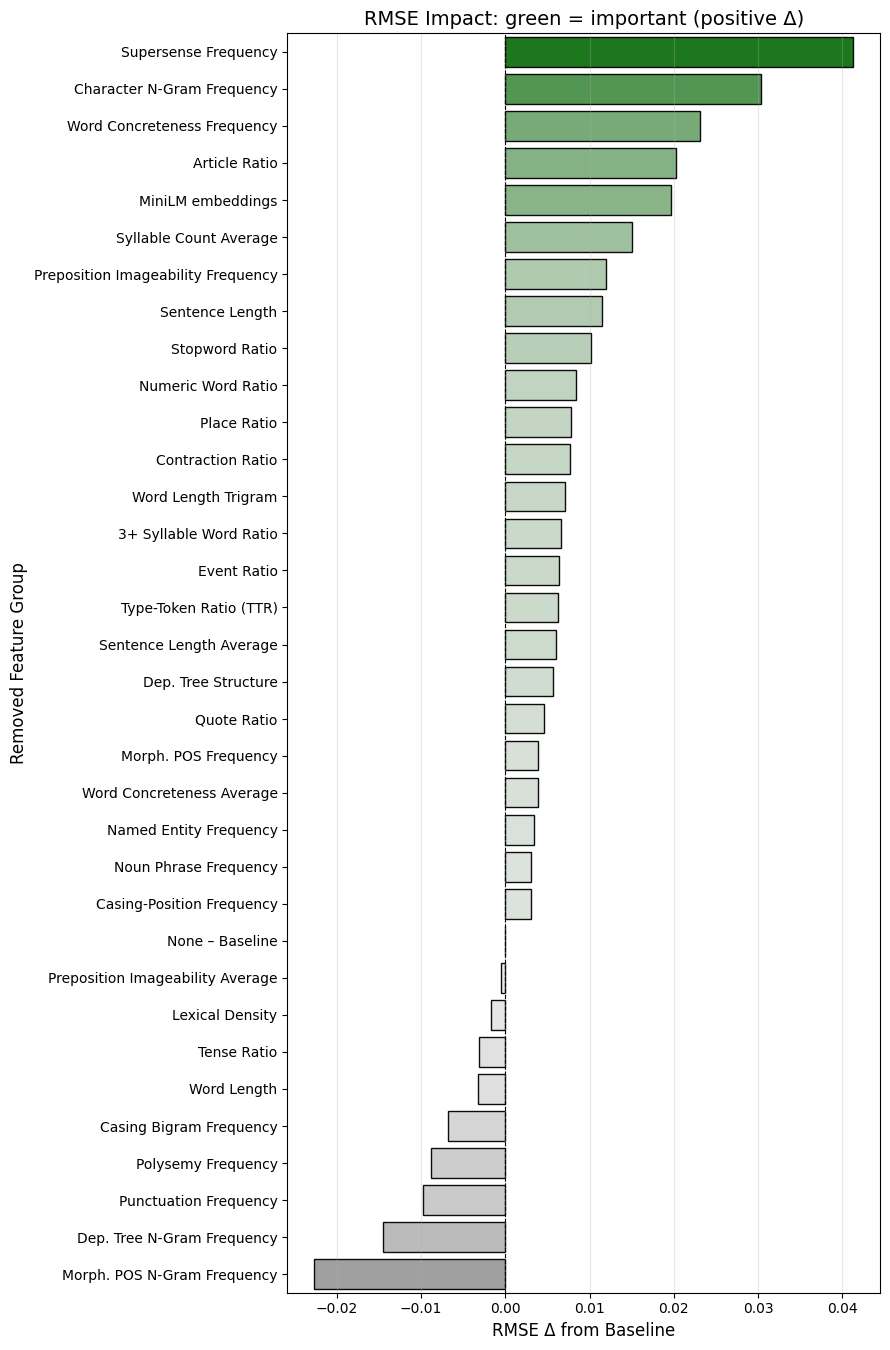

Saved RMSE delta plot -> data/figures/feature_importance_rmse_delta.pdf


In [4]:
plot_feature_importance_bars(df)